In [1]:
from dotenv import load_dotenv
from pathlib import Path
import sys
import os

# Walk up until we find the project root (folder with the .env)
current_path = Path().resolve()
for parent in [current_path] + list(current_path.parents):
    if (parent / ".env").exists():
        load_dotenv(parent / ".env")
        project_root = os.getenv("PROJECT_ROOT")
        print(project_root)
        sys.path.append(project_root)     
        break


%load_ext autoreload
%autoreload 2

/Users/emmanuel/Documents/belugas/beluga-call-pipeline


In [2]:

import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import librosa
from data_preprocessing.spectrogram.spectrogram_generator import HYDROPHONE_SENSITIVITY, SpectrogramGenerator
import pandas as pd
import torch

from tqdm import tqdm
import os
pd.set_option('display.max_columns', None)

#Loading the labels for the overlaps
overlaps_df = pd.read_csv("../data/labels/Overlaps_1s.csv")

spect_generator = SpectrogramGenerator(
        n_fft=2048,
        hop_length=int(2048/2),
        n_mels=64,
        fmin=200,
        sample_rate=192000, 
    )

In [3]:
overlaps_df[["SnippetFilename", "CC", "HFPC"]]

,SnippetFilename,CC,HFPC
0,BSM_20170724_13014300.wav,0,0
1,BSM_20170724_13014300.wav,0,1
2,BSM_20170724_13014300.wav,0,0
3,BSM_20170724_13062370.wav,0,1
4,BSM_20170724_13062370.wav,0,1
...,...,...,...
10928,CAC_20210714_09242300.wav,0,0
10929,CAC_20210714_09242800.wav,0,0
10930,CAC_20210714_09251600.wav,0,0
10931,CAC_20210714_09271800.wav,0,0


In [95]:
# Step 1: Find all SnippetFilenames that have at least one row with CC=1 or HFPC=1
filenames_with_calls = overlaps_df[
    (overlaps_df['CC'] == 1) | (overlaps_df['HFPC'] == 1)
]['SnippetFilename'].unique()

# Step 2: Filter to rows with those filenames
temp_df = overlaps_df[overlaps_df['SnippetFilename'].isin(filenames_with_calls)]

# Step 2.5: Filter to only filenames that have exactly 3 rows
filename_counts = temp_df['SnippetFilename'].value_counts()
filenames_with_3_rows = filename_counts[filename_counts == 3].index

# Step 3: Get 100 unique filenames per site (from those with exactly 3 rows)
selected_filenames = temp_df[temp_df['SnippetFilename'].isin(filenames_with_3_rows)].groupby('Site')['SnippetFilename'].apply(
    lambda x: pd.Series(x.unique()).sample(n=min(100, len(x.unique())), random_state=42).tolist()
).explode().values


# Step 4: Build sample_20min by iterating through selected_filenames in order
sample_20min_list = []
for filename in selected_filenames:
    rows = overlaps_df[overlaps_df['SnippetFilename'] == filename]
    sample_20min_list.append(rows)

sample_20min = pd.concat(sample_20min_list, ignore_index=True)

# Step 5: Add seconds_since_file_start column
sample_20min['seconds_since_file_start'] = range(len(sample_20min))

# Check the results
print(f"Total rows: {len(sample_20min)}")
print(f"Total unique filenames: {sample_20min['SnippetFilename'].nunique()}")
print(f"\nUnique filenames per site:")
print(sample_20min.groupby('Site')['SnippetFilename'].nunique())
print(f"\nTotal rows per site:")
print(sample_20min['Site'].value_counts())

# Verify order matches
print(f"\nOrder matches: {list(sample_20min['SnippetFilename'].unique()) == list(selected_filenames)}")


Total rows: 1200
Total unique filenames: 400

Unique filenames per site:
Site
BSM    100
CAC    100
KAM    100
RDL    100
Name: SnippetFilename, dtype: int64

Total rows per site:
Site
BSM    300
CAC    300
KAM    300
RDL    300
Name: count, dtype: int64

Order matches: True


In [96]:
print(sample_20min["SnippetFilename"].head(5))
print(selected_filenames[:5])

0    BSM_20170801_18595800.wav
1    BSM_20170801_18595800.wav
2    BSM_20170801_18595800.wav
3    BSM_20170810_16050029.wav
4    BSM_20170810_16050029.wav
Name: SnippetFilename, dtype: object
['BSM_20170801_18595800.wav' 'BSM_20170810_16050029.wav'
 'BSM_20170808_14090529.wav' 'BSM_20170801_19215570.wav'
 'BSM_20170729_16034500.wav']


In [97]:
# Check if for any SnippetFilename there is any that doesn't have exactly 3 rows
row_counts = sample_20min['SnippetFilename'].value_counts()
not_3_rows = row_counts[row_counts != 3]
if not not_3_rows.empty:
    print("SnippetFilenames without exactly 3 rows:")
    print(not_3_rows)
else:
    print("All SnippetFilenames have exactly 3 rows.")



All SnippetFilenames have exactly 3 rows.


## Creating the merged file

In [98]:
import numpy as np
import soundfile as sf
from pathlib import Path

# Directory containing the snippet files
snippets_dir = "../data/Full_Dataset/Snippets_3s_wav/"

# Initialize lists to store audio data and track sample rates
audio_segments = []
sample_rates = []

print(f"Loading {len(selected_filenames)} audio files...")

# Read each selected file
for i, filename in enumerate(selected_filenames):
    file_path = Path(snippets_dir) / filename
    print(filename)
    if file_path.exists():
        # Load audio file
        audio, sr = librosa.load(file_path, sr=None)  # sr=None keeps original sample rate
        audio_segments.append(audio)

        if sr not in sample_rates:
            print(f"Adding new sample rate: {sr} for file {filename}")
        sample_rates.append(sr)
        
        if (i + 1) % 50 == 0:
            print(f"Loaded {i + 1}/{len(selected_filenames)} files...")

    else:
        print(f"Warning: File not found: {filename}")

# Check if all sample rates are the same
unique_sample_rates = set(sample_rates)
if len(unique_sample_rates) > 1:
    print(f"Warning: Multiple sample rates found: {unique_sample_rates}")
    print("All files will be resampled to the lowest sample rate.")
    # Get the most common sample rate
    target_sr = min(sample_rates)
    print(f"Resampling all files to {target_sr} Hz")
else:
    target_sr = sample_rates[0]
    print(f"All files have the same sample rate: {target_sr} Hz")


Loading 400 audio files...
BSM_20170801_18595800.wav
Adding new sample rate: 288000 for file BSM_20170801_18595800.wav
BSM_20170810_16050029.wav
BSM_20170808_14090529.wav
BSM_20170801_19215570.wav
BSM_20170729_16034500.wav
BSM_20170724_13220050.wav
BSM_20170801_16441879.wav
BSM_20170801_17455200.wav
BSM_20170801_17585920.wav
BSM_20170729_12433750.wav
BSM_20170724_13090979.wav
BSM_20170801_16431770.wav
BSM_20170729_14153470.wav
BSM_20170801_18554559.wav
BSM_20170808_14093759.wav
BSM_20170729_14184020.wav
BSM_20170801_16510120.wav
BSM_20170801_16035820.wav
BSM_20170801_17504679.wav
BSM_20170801_16091820.wav
BSM_20170801_18482540.wav
BSM_20170810_15282950.wav
BSM_20170809_15404650.wav
BSM_20170725_13590229.wav
BSM_20170801_17243070.wav
BSM_20170810_14210340.wav
BSM_20170810_14235509.wav
BSM_20170801_15401420.wav
BSM_20170801_16253609.wav
BSM_20170801_16250490.wav
BSM_20170801_17111720.wav
BSM_20170810_15543300.wav
BSM_20170801_17583770.wav
BSM_20170729_13182740.wav
BSM_20170724_13562009.w

In [99]:

# Resample if necessary and concatenate
resampled_segments = []
for audio, sr in zip(audio_segments, sample_rates):
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
    resampled_segments.append(audio)

# Concatenate all audio segments
merged_audio = np.concatenate(resampled_segments)

# Calculate duration
duration_seconds = len(merged_audio) / target_sr
duration_minutes = duration_seconds / 60

print(f"\nMerged audio stats:")
print(f"  - Total duration: {duration_minutes:.2f} minutes ({duration_seconds:.2f} seconds)")
print(f"  - Sample rate: {target_sr} Hz")
print(f"  - Total samples: {len(merged_audio)}")
print(f"  - Number of files merged: {len(audio_segments)}")




Merged audio stats:
  - Total duration: 20.00 minutes (1200.00 seconds)
  - Sample rate: 192000 Hz
  - Total samples: 230400000
  - Number of files merged: 400


In [100]:
# Save the merged audio file
output_path = "./snippets/old_dataset_merged/cc_hfpc_20min.wav"
sf.write(output_path, merged_audio, target_sr)

print(f"\nMerged audio saved to: {output_path}")


Merged audio saved to: ./snippets/old_dataset_merged/cc_hfpc_20min.wav


## Creating the raven file

In [102]:
def translate_to_raven(labels_df, sample_rate):
    # Create new dataframe with Raven format columns
    
    raven_df = pd.DataFrame()
    raven_df["Selection"] = [x + 1 for x in labels_df.index.tolist()]
    raven_df["View"] = "Spectrogram 1"
    raven_df["Channel"] = 1
    # Begin Time is seconds since start
    raven_df["Begin Time (s)"] = labels_df["seconds_since_file_start"]
    
    # End Time is Begin Time + 1 second window
    raven_df["End Time (s)"] = labels_df["seconds_since_file_start"] + 1.0
    
    # Low Freq is 0 Hz
    raven_df["Low Freq (Hz)"] = 0.0
    
    # High Freq is Nyquist frequency (sample_rate/2)
    raven_df["High Freq (Hz)"] = sample_rate / 2

    raven_df["ECHO"] = labels_df["ECHO"]
    raven_df["HFPC"] = labels_df["HFPC"]
    raven_df["BBPC"] = labels_df["CC"]
    raven_df["Whistle"] = labels_df["Whistle"]

    raven_df["GROUNDTRUTH"] = ""
    raven_df["DETAIL"] = ""
    raven_df["Notes"] = ""
    raven_df["SnippetFilename"] = labels_df["SnippetFilename"]
    
    return raven_df
    

In [78]:
sample_20min["SnippetFilename"]

0       BSM_20170724_13090979.wav
1       BSM_20170724_13090979.wav
2       BSM_20170724_13090979.wav
3       BSM_20170724_13132559.wav
4       BSM_20170724_13132559.wav
                  ...            
1195    CAC_20210724_19493300.wav
1196    CAC_20210724_19493300.wav
1197    CAC_20210724_19494100.wav
1198    CAC_20210724_19494100.wav
1199    CAC_20210724_19494100.wav
Name: SnippetFilename, Length: 1200, dtype: object

In [103]:
sample_20min = sample_20min.reset_index(drop=True)

raven_df = translate_to_raven(sample_20min, 192000)
raven_df.to_csv("./snippets/old_dataset_merged/cc_hfpc_20min.Table.1.selections.txt", sep="\t", index=False)

In [83]:
raven_df

,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),ECHO,HFPC,BBPC,Whistle,GROUNDTRUTH,DETAIL,Notes,SnippetFilename
0,1,Spectrogram 1,1,0,1.0,0.0,96000.0,0,1,0,1,,,,BSM_20170724_13090979.wav
1,2,Spectrogram 1,1,1,2.0,0.0,96000.0,0,0,0,1,,,,BSM_20170724_13090979.wav
2,3,Spectrogram 1,1,2,3.0,0.0,96000.0,0,0,0,1,,,,BSM_20170724_13090979.wav
3,4,Spectrogram 1,1,3,4.0,0.0,96000.0,0,1,0,0,,,,BSM_20170724_13132559.wav
4,5,Spectrogram 1,1,4,5.0,0.0,96000.0,0,1,0,0,,,,BSM_20170724_13132559.wav
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,1196,Spectrogram 1,1,1195,1196.0,0.0,96000.0,0,0,1,1,,,,CAC_20210724_19493300.wav
1196,1197,Spectrogram 1,1,1196,1197.0,0.0,96000.0,0,0,1,1,,,,CAC_20210724_19493300.wav
1197,1198,Spectrogram 1,1,1197,1198.0,0.0,96000.0,0,0,1,1,,,,CAC_20210724_19494100.wav
1198,1199,Spectrogram 1,1,1198,1199.0,0.0,96000.0,0,0,1,1,,,,CAC_20210724_19494100.wav


In [84]:
# Check if for any SnippetFilename there is any that doesn't have exactly 3 rows
row_counts = raven_df['SnippetFilename'].value_counts()
not_3_rows = row_counts[row_counts != 3]
if not not_3_rows.empty:
    print("SnippetFilenames without exactly 3 rows:")
    print(not_3_rows)
else:
    print("All SnippetFilenames have exactly 3 rows.")


All SnippetFilenames have exactly 3 rows.


In [42]:
spect_generator_192000 = SpectrogramGenerator(
        n_fft=2048,
        hop_length=int(2048/2),
        n_mels=64,
        fmin=200,
        sample_rate=192000, 
    )

spect_generator_288000 = SpectrogramGenerator(
    n_fft=2048,
    hop_length=int(2048/2),
    n_mels=64,
    fmin=200,
    sample_rate=288000, 
)

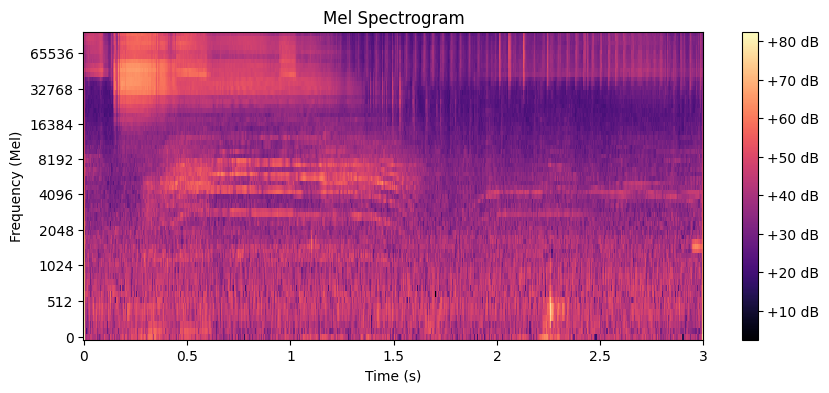

In [105]:
audio_path =snippets_dir +  "BSM_20170808_14090529.wav"

audio, sr, original_sr = spect_generator_192000.load_audio(audio_path)

power_spect = spect_generator_192000.compute_mel_power_spect(audio)

dB_spect = spect_generator_192000.power_to_db(power_spect)

spect_generator_192000.plot_spect(dB_spect)
# dB_spect_normalized = spect_generator.min_max_normalization(dB_spect)

# dB_spect_resized = spect_generator.resize_spect(dB_spect_normalized, img_shape=(244,244))


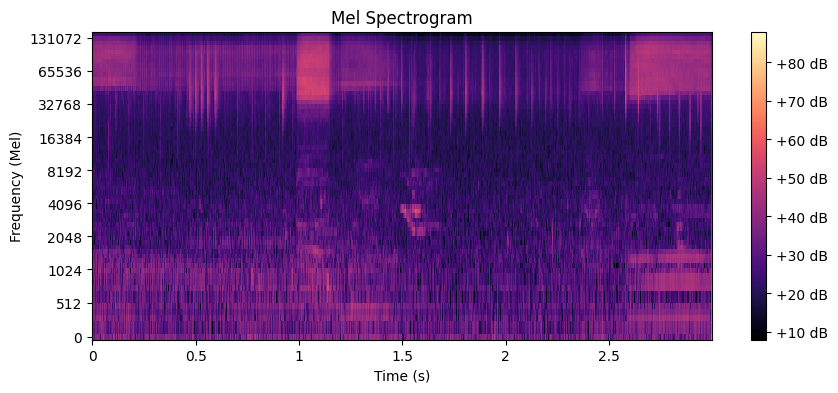

In [44]:
audio, sr, original_sr = spect_generator_288000.load_audio(audio_path)

power_spect = spect_generator_288000.compute_mel_power_spect(audio)

dB_spect = spect_generator_288000.power_to_db(power_spect)

spect_generator_288000.plot_spect(dB_spect)